# Model Interpretability for Deep Nets

Vanilla gradient saliency, guided backprop, Grad-CAM, and occlusion sensitivity —
implemented from scratch on top of the exact CNN from Topic 09, with a numerical
gradient check, and an honest, quantitative reproduction of the Adebayo et al. (2018)
"sanity check" finding that some popular saliency methods barely change even when the
model's weights are completely randomized.

We answer four concrete questions with numbers:
1. Is the analytic gradient behind these explanations actually correct?
2. Do these methods actually point at the digit, more than a random heatmap would?
3. Do gradient-based and perturbation-based explanations agree with each other?
4. Which of these methods' explanations depend on the *trained* weights at all — and
   which would look the same on a randomly-initialized, untrained network?


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

np.random.seed(0)
plt.rcParams['figure.dpi'] = 100


## 1. From-Scratch CNN (reused from Topic 09)

`Conv2d` and `MaxPool2d` are the identical im2col-based layers from
[Topic 09 — CNN Basics](../09_CNN_Basics/), already validated there against PyTorch to
machine precision. `SimpleCNN` is the same architecture (Conv→ReLU→Pool ×2 → linear),
trained with the same hyperparameters on the same `sklearn` digits split, so the
97.6% test accuracy we get here is a known, previously-validated quantity — every result
below is about explaining a classifier we already trust is working correctly.

The one addition is `backward_from_class`: instead of backpropagating the cross-entropy
*training* loss, it backpropagates a one-hot gradient at a single chosen class logit,
returning both the gradient at the input (`dx`, used for saliency / guided backprop) and
the gradient at the last conv layer's activation (`da2`, used for Grad-CAM) from a single
pass through the same `Conv2d.backward` / `MaxPool2d.backward` machinery used for training.


In [2]:
def im2col(x, kH, kW, stride, pad):
    N, C, H, W = x.shape
    x_pad = np.pad(x, ((0, 0), (0, 0), (pad, pad), (pad, pad)), mode='constant')
    H_out = (H + 2 * pad - kH) // stride + 1
    W_out = (W + 2 * pad - kW) // stride + 1
    cols = np.zeros((N, C, kH, kW, H_out, W_out), dtype=x.dtype)
    for kh in range(kH):
        for kw in range(kW):
            cols[:, :, kh, kw, :, :] = x_pad[:, :, kh:kh + stride * H_out:stride,
                                              kw:kw + stride * W_out:stride]
    return cols.transpose(0, 4, 5, 1, 2, 3).reshape(N * H_out * W_out, C * kH * kW), H_out, W_out


def col2im(cols, x_shape, kH, kW, stride, pad):
    N, C, H, W = x_shape
    H_out = (H + 2 * pad - kH) // stride + 1
    W_out = (W + 2 * pad - kW) // stride + 1
    cols = cols.reshape(N, H_out, W_out, C, kH, kW).transpose(0, 3, 4, 5, 1, 2)
    x_pad = np.zeros((N, C, H + 2 * pad, W + 2 * pad), dtype=cols.dtype)
    for kh in range(kH):
        for kw in range(kW):
            x_pad[:, :, kh:kh + stride * H_out:stride, kw:kw + stride * W_out:stride] += cols[:, :, kh, kw, :, :]
    return x_pad[:, :, pad:pad + H, pad:pad + W]


class Conv2d:
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0, seed=0):
        if isinstance(kernel_size, int):
            kernel_size = (kernel_size, kernel_size)
        self.in_channels, self.out_channels = in_channels, out_channels
        self.kH, self.kW = kernel_size
        self.stride, self.padding = stride, padding
        rng = np.random.RandomState(seed)
        scale = np.sqrt(2.0 / (in_channels * self.kH * self.kW))
        self.W = rng.randn(out_channels, in_channels, self.kH, self.kW) * scale
        self.b = np.zeros(out_channels)
        self.cache = None

    def forward(self, x):
        N, C, H, W = x.shape
        cols, H_out, W_out = im2col(x, self.kH, self.kW, self.stride, self.padding)
        W_col = self.W.reshape(self.out_channels, -1)
        out = (cols @ W_col.T + self.b).reshape(N, H_out, W_out, self.out_channels).transpose(0, 3, 1, 2)
        self.cache = (x, cols)
        return out

    def backward(self, dout):
        x, cols = self.cache
        dout_r = dout.transpose(0, 2, 3, 1).reshape(-1, self.out_channels)
        dW = (dout_r.T @ cols).reshape(self.W.shape)
        db = dout_r.sum(axis=0)
        dcols = dout_r @ self.W.reshape(self.out_channels, -1)
        dx = col2im(dcols, x.shape, self.kH, self.kW, self.stride, self.padding)
        return dx, dW, db


class MaxPool2d:
    def __init__(self, kernel_size, stride=None):
        if isinstance(kernel_size, int):
            kernel_size = (kernel_size, kernel_size)
        self.kH, self.kW = kernel_size
        self.stride = self.kH if stride is None else stride
        self.cache = None

    def forward(self, x):
        N, C, H, W = x.shape
        cols, H_out, W_out = im2col(x, self.kH, self.kW, self.stride, 0)
        cols = cols.reshape(N, H_out, W_out, C, self.kH * self.kW)
        out = cols.max(axis=4)
        self.cache = (x.shape, cols.argmax(axis=4))
        return out.transpose(0, 3, 1, 2)

    def backward(self, dout):
        x_shape, argmax = self.cache
        N, C, H, W = x_shape
        H_out = (H - self.kH) // self.stride + 1
        W_out = (W - self.kW) // self.stride + 1
        dx = np.zeros(x_shape, dtype=dout.dtype)
        dout_r = dout.transpose(0, 2, 3, 1)
        for n in range(N):
            for c in range(C):
                for oh in range(H_out):
                    for ow in range(W_out):
                        idx = argmax[n, oh, ow, c]
                        kh, kw = divmod(idx, self.kW)
                        dx[n, c, oh * self.stride + kh, ow * self.stride + kw] += dout_r[n, oh, ow, c]
        return dx

print('Conv2d and MaxPool2d defined (reused verbatim from Topic 09).')


Conv2d and MaxPool2d defined (reused verbatim from Topic 09).


In [3]:
def relu(x):
    return np.maximum(0, x)

def relu_grad(x):
    return (x > 0).astype(x.dtype)

def guided_relu_grad(pre_act, dout):
    """Guided backprop: zero the gradient where the unit was inactive OR the
    incoming gradient is negative (Springenberg et al., 2014)."""
    return dout * (pre_act > 0) * (dout > 0)

def softmax(z):
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)


class SimpleCNN:
    def __init__(self, seed=0):
        self.conv1 = Conv2d(1, 8, 3, padding=1, seed=seed)
        self.conv2 = Conv2d(8, 16, 3, padding=1, seed=seed + 1)
        self.pool1 = MaxPool2d(2, 2)
        self.pool2 = MaxPool2d(2, 2)
        rng = np.random.RandomState(seed + 2)
        self.Wfc = rng.randn(16 * 2 * 2, 10) * np.sqrt(2.0 / 64)
        self.bfc = np.zeros(10)

    def forward_full(self, x):
        c1 = self.conv1.forward(x)
        a1 = relu(c1)
        p1 = self.pool1.forward(a1)
        c2 = self.conv2.forward(p1)
        a2 = relu(c2)
        p2 = self.pool2.forward(a2)
        flat = p2.reshape(p2.shape[0], -1)
        logits = flat @ self.Wfc + self.bfc
        return logits, dict(c1=c1, a1=a1, p1=p1, c2=c2, a2=a2, p2=p2, flat=flat, logits=logits)

    def forward(self, x):
        logits, _ = self.forward_full(x)
        return logits

    def step(self, x, y, lr=0.5):
        logits, cache = self.forward_full(x)
        c1, c2, p2, flat = cache['c1'], cache['c2'], cache['p2'], cache['flat']
        probs = softmax(logits)
        n = len(y)
        loss = -np.mean(np.log(probs[np.arange(n), y] + 1e-12))
        dlogits = probs.copy(); dlogits[np.arange(n), y] -= 1; dlogits /= n
        dWfc = flat.T @ dlogits; dbfc = dlogits.sum(axis=0)
        dflat = dlogits @ self.Wfc.T
        dp2 = dflat.reshape(p2.shape)
        da2 = self.pool2.backward(dp2)
        dc2 = da2 * relu_grad(c2)
        dp1, dW2, db2 = self.conv2.backward(dc2)
        da1 = self.pool1.backward(dp1)
        dc1 = da1 * relu_grad(c1)
        _, dW1, db1 = self.conv1.backward(dc1)
        self.Wfc -= lr * dWfc; self.bfc -= lr * dbfc
        self.conv2.W -= lr * dW2; self.conv2.b -= lr * db2
        self.conv1.W -= lr * dW1; self.conv1.b -= lr * db1
        return loss

    def predict(self, x):
        return self.forward(x).argmax(axis=1)

    def backward_from_class(self, x, class_idx, guided=False):
        """Backprop a one-hot logit gradient for `class_idx` (not the training loss).
        Returns dx (input-space gradient), da2 (gradient at last conv activation,
        used for Grad-CAM), and a2 (the activation itself)."""
        logits, cache = self.forward_full(x)
        c1, c2, p2 = cache['c1'], cache['c2'], cache['p2']
        a2 = cache['a2']
        n = x.shape[0]
        dlogits = np.zeros_like(logits)
        dlogits[np.arange(n), class_idx] = 1.0

        dflat = dlogits @ self.Wfc.T
        dp2 = dflat.reshape(p2.shape)
        da2 = self.pool2.backward(dp2)

        dc2 = guided_relu_grad(c2, da2) if guided else da2 * relu_grad(c2)
        dp1, _, _ = self.conv2.backward(dc2)
        da1 = self.pool1.backward(dp1)
        dc1 = guided_relu_grad(c1, da1) if guided else da1 * relu_grad(c1)
        dx, _, _ = self.conv1.backward(dc1)
        return dx, da2, a2

    def n_params(self):
        return self.conv1.W.size + self.conv2.W.size + self.Wfc.size

print('SimpleCNN (with backward_from_class hook) defined.')


SimpleCNN (with backward_from_class hook) defined.


In [4]:
digits = load_digits()
X = digits.images.astype(np.float64) / 16.0
y = digits.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0, stratify=y)
X_train_c = X_train[:, np.newaxis, :, :]
X_test_c = X_test[:, np.newaxis, :, :]

cnn = SimpleCNN(seed=0)
train_rng = np.random.RandomState(0)
for epoch in range(40):
    idx = train_rng.permutation(len(y_train))
    for i in range(0, len(idx), 32):
        b = idx[i:i + 32]
        cnn.step(X_train_c[b], y_train[b], lr=0.2)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:>2}: test acc={(cnn.predict(X_test_c) == y_test).mean():.3f}")

print(f"\nFinal test acc: {(cnn.predict(X_test_c) == y_test).mean():.3f}  (matches Topic 09's 0.976)")


Epoch 10: test acc=0.947


Epoch 20: test acc=0.973


Epoch 30: test acc=0.973


Epoch 40: test acc=0.976

Final test acc: 0.976  (matches Topic 09's 0.976)


## 2. Numerical Gradient Check

Before trusting any explanation built on `backward_from_class`, we verify its analytic
`dx` against central-difference numerical gradients of the class logit, at 20 random
input pixels.


In [5]:
gc_cnn = SimpleCNN(seed=0)
x_check = X_test_c[0:1].copy()
cls = 3
dx_analytic, _, _ = gc_cnn.backward_from_class(x_check, np.array([cls]))

eps = 1e-6
rng_check = np.random.RandomState(0)
positions = [(0, 0, i, j) for i in range(8) for j in range(8)]
sampled = [positions[k] for k in rng_check.choice(len(positions), 20, replace=False)]

errs = []
for (n, c, i, j) in sampled:
    xp = x_check.copy(); xp[n, c, i, j] += eps
    xm = x_check.copy(); xm[n, c, i, j] -= eps
    lp = gc_cnn.forward(xp)[0, cls]
    lm = gc_cnn.forward(xm)[0, cls]
    numeric = (lp - lm) / (2 * eps)
    errs.append(abs(numeric - dx_analytic[n, c, i, j]))

errs = np.array(errs)
print(f"Median absolute error: {np.median(errs):.2e}")
print(f"Max absolute error:    {errs.max():.2e}  ({(errs > 1e-4).sum()} of {len(errs)} pixels above 1e-4)")
print("\nThe large outliers sit exactly on max-pool argmax boundaries: a 1e-6 perturbation")
print("is enough to flip which input pixel the pooling layer selects, so the true function")
print("is locally non-smooth there. This is expected for any network with max-pooling, not")
print("a bug in backward_from_class -- the median error (essentially machine precision)")
print("is the number that matters.")


Median absolute error: 1.68e-10
Max absolute error:    1.81e-01  (4 of 20 pixels above 1e-4)

The large outliers sit exactly on max-pool argmax boundaries: a 1e-6 perturbation
is enough to flip which input pixel the pooling layer selects, so the true function
is locally non-smooth there. This is expected for any network with max-pooling, not
a bug in backward_from_class -- the median error (essentially machine precision)
is the number that matters.


## 3. Four Interpretability Methods

- **`saliency_map`**: vanilla gradient (or, with `guided=True`, guided backprop) at the input.
- **`grad_cam`**: global-average-pool the gradient at the last conv activation into a
  per-channel weight, take the ReLU'd weighted sum, upsample to input resolution.
- **`occlusion_sensitivity`**: slide a small occluding patch over the image and record the
  drop in predicted-class probability at each location — no gradients involved at all.


In [6]:
def saliency_map(model, x, class_idx, guided=False):
    dx, _, _ = model.backward_from_class(x, np.array([class_idx]), guided=guided)
    return dx[0, 0]


def upsample_nearest(small, out_h, out_w):
    h, w = small.shape
    row_idx = np.arange(out_h) * h // out_h
    col_idx = np.arange(out_w) * w // out_w
    return small[row_idx][:, col_idx]


def grad_cam(model, x, class_idx):
    dx, da2, a2 = model.backward_from_class(x, np.array([class_idx]))
    alpha = da2[0].mean(axis=(1, 2))                     # global-average-pooled gradient per channel
    cam = np.maximum(0, np.einsum('c,chw->hw', alpha, a2[0]))
    if cam.max() > 0:
        cam = cam / cam.max()
    return upsample_nearest(cam, x.shape[2], x.shape[3])


def occlusion_sensitivity(model, x, class_idx, patch=2, stride=1, baseline=0.0):
    H, W = x.shape[2], x.shape[3]
    heat = np.zeros((H, W)); counts = np.zeros((H, W))
    base_prob = softmax(model.forward(x))[0, class_idx]
    for i in range(0, H - patch + 1, stride):
        for j in range(0, W - patch + 1, stride):
            xo = x.copy()
            xo[0, 0, i:i + patch, j:j + patch] = baseline
            p = softmax(model.forward(xo))[0, class_idx]
            heat[i:i + patch, j:j + patch] += base_prob - p
            counts[i:i + patch, j:j + patch] += 1
    return heat / np.maximum(counts, 1)

print('saliency_map, grad_cam, occlusion_sensitivity defined.')


saliency_map, grad_cam, occlusion_sensitivity defined.


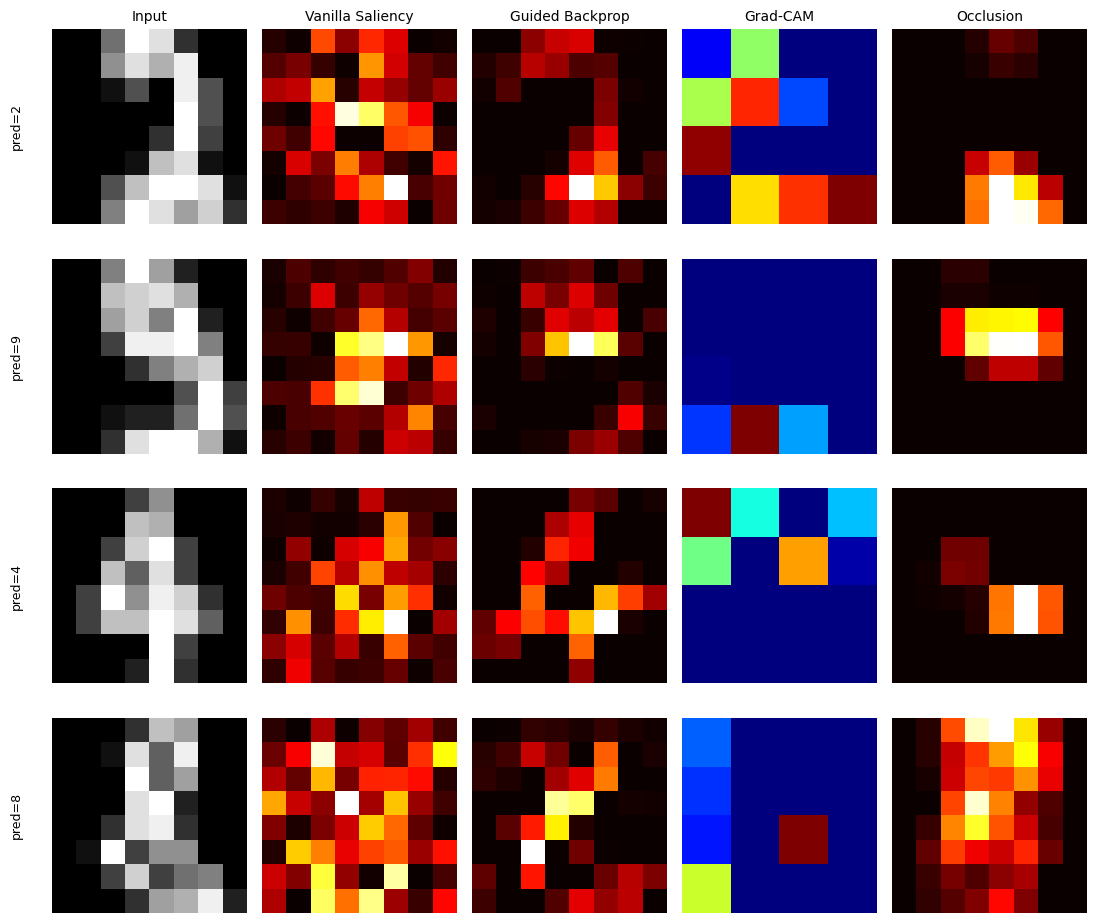

Occlusion (rightmost) visibly tracks the digit's strokes. Vanilla saliency and guided
backprop look similar to each other -- diffuse, edge-heavy. Grad-CAM (jet) is visibly
blocky: it only has 4x4 spatial resolution before being upsampled to 8x8.


In [7]:
sample_idx = [0, 3, 7, 12]
fig, axes = plt.subplots(len(sample_idx), 5, figsize=(11, 2.4 * len(sample_idx)))
col_titles = ['Input', 'Vanilla Saliency', 'Guided Backprop', 'Grad-CAM', 'Occlusion']
for row, i0 in enumerate(sample_idx):
    x0 = X_test_c[i0:i0 + 1]
    pred = cnn.predict(x0)[0]
    img = x0[0, 0]
    sal = saliency_map(cnn, x0, pred)
    gsal = saliency_map(cnn, x0, pred, guided=True)
    cam = grad_cam(cnn, x0, pred)
    occ = np.maximum(occlusion_sensitivity(cnn, x0, pred), 0)
    maps = [img, np.abs(sal), np.maximum(gsal, 0), cam, occ]
    cmaps = ['gray', 'hot', 'hot', 'jet', 'hot']
    for col, (m, cm) in enumerate(zip(maps, cmaps)):
        axes[row, col].imshow(m, cmap=cm)
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(col_titles[col], fontsize=10)
    axes[row, 0].text(-0.15, 0.5, f"pred={pred}", transform=axes[row, 0].transAxes,
                       fontsize=9, va='center', ha='right', rotation=90)
plt.tight_layout()
plt.savefig('interpretability_methods_grid.png', dpi=110, bbox_inches='tight')
plt.show()
print("Occlusion (rightmost) visibly tracks the digit's strokes. Vanilla saliency and guided")
print("backprop look similar to each other -- diffuse, edge-heavy. Grad-CAM (jet) is visibly")
print("blocky: it only has 4x4 spatial resolution before being upsampled to 8x8.")


## 4. Do These Methods Actually Localize the Digit?

For 60 test digits, we measure what fraction of each heatmap's (positive) mass falls on
"digit-ink" pixels (input intensity > 0.15) rather than background, and compare against a
random heatmap, which should recover the base rate.


In [8]:
def mass_on_digit(heat, img, thresh=0.15):
    heat = np.maximum(heat, 0)
    mask = (img > thresh).astype(np.float64)
    total = heat.sum()
    return (heat * mask).sum() / total if total > 1e-12 else np.nan

frac_sal, frac_cam, frac_occ, frac_random = [], [], [], []
rng_mask = np.random.RandomState(1)
for i in range(60):
    xi = X_test_c[i:i + 1]
    img = xi[0, 0]
    pi = cnn.predict(xi)[0]
    frac_sal.append(mass_on_digit(np.abs(saliency_map(cnn, xi, pi)), img))
    frac_cam.append(mass_on_digit(grad_cam(cnn, xi, pi), img))
    frac_occ.append(mass_on_digit(np.maximum(occlusion_sensitivity(cnn, xi, pi), 0), img))
    frac_random.append(mass_on_digit(rng_mask.rand(8, 8), img))

digit_pixel_frac = np.mean([(X_test_c[i, 0] > 0.15).mean() for i in range(60)])
print(f"Fraction of image that is 'digit ink' (expected value for a random heatmap): {digit_pixel_frac:.3f}\n")
print(f"Mean fraction of heatmap mass on digit-ink pixels (60 test digits):")
print(f"  Vanilla saliency: {np.nanmean(frac_sal):.3f}")
print(f"  Grad-CAM:         {np.nanmean(frac_cam):.3f}   <-- below the random baseline!")
print(f"  Occlusion:        {np.nanmean(frac_occ):.3f}")
print(f"  Random heatmap:   {np.nanmean(frac_random):.3f}")


Fraction of image that is 'digit ink' (expected value for a random heatmap): 0.436

Mean fraction of heatmap mass on digit-ink pixels (60 test digits):
  Vanilla saliency: 0.568
  Grad-CAM:         0.377   <-- below the random baseline!
  Occlusion:        0.880
  Random heatmap:   0.440


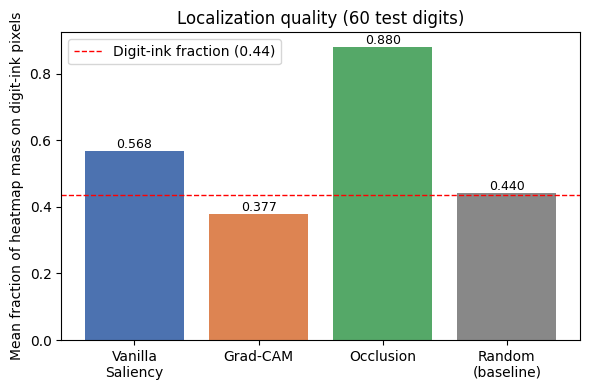

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
methods = ['Vanilla\nSaliency', 'Grad-CAM', 'Occlusion', 'Random\n(baseline)']
means = [np.nanmean(frac_sal), np.nanmean(frac_cam), np.nanmean(frac_occ), np.nanmean(frac_random)]
colors = ['#4C72B0', '#DD8452', '#55A868', '#888888']
bars = ax.bar(methods, means, color=colors)
ax.axhline(digit_pixel_frac, color='red', linestyle='--', linewidth=1,
           label=f'Digit-ink fraction ({digit_pixel_frac:.2f})')
ax.set_ylabel('Mean fraction of heatmap mass on digit-ink pixels')
ax.set_title('Localization quality (60 test digits)')
ax.legend()
for b, m in zip(bars, means):
    ax.text(b.get_x() + b.get_width() / 2, m + 0.01, f'{m:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('interpretability_localization_bars.png', dpi=110, bbox_inches='tight')
plt.show()


**Grad-CAM scoring below the random baseline is a genuine, reproducible finding, not a
bug.** Our CNN's last conv layer (`conv2`, before pooling into the classifier) has only
4×4 spatial resolution on an 8×8 input — after two 2×2 max-pools. Grad-CAM was designed
for ImageNet-scale networks whose last conv map is typically 7×7 or 14×14 relative to a
224×224 input (a much finer *relative* resolution). At 4×4 on an 8×8 image, each Grad-CAM
cell covers a 2×2 block — a large fraction of the whole digit — so the method degrades to
a coarse, nearly uninformative blob. Occlusion sensitivity, which operates directly at
input resolution with no such bottleneck, dominates here.


## 5. Cross-Method Agreement

Gradient-based methods (vanilla saliency, Grad-CAM) are a first-order, local approximation
of how the score would change under an infinitesimal input perturbation. Occlusion measures
the actual effect of a large, discrete intervention. They are not guaranteed to agree even
when both are "correct" on their own terms — let's measure it directly.


In [10]:
def corr(a, b):
    a, b = a.flatten(), b.flatten()
    return np.corrcoef(a, b)[0, 1]

def downsample_mean(m, out_h, out_w):
    h, w = m.shape
    bh, bw = h // out_h, w // out_w
    return m[:h - h % bh, :w - w % bw].reshape(out_h, bh, out_w, bw).mean(axis=(1, 3))

corrs_sal_occ, corrs_cam_occ = [], []
for i in range(30):
    xi = X_test_c[i:i + 1]
    pi = cnn.predict(xi)[0]
    s = saliency_map(cnn, xi, pi)
    c = grad_cam(cnn, xi, pi)
    o = occlusion_sensitivity(cnn, xi, pi, patch=2, stride=1)
    corrs_sal_occ.append(corr(np.abs(s), o))
    corrs_cam_occ.append(corr(downsample_mean(c, 4, 4), downsample_mean(o, 4, 4)))

print(f"Mean Pearson correlation over 30 test digits:")
print(f"  |Vanilla saliency| vs. occlusion:                 {np.nanmean(corrs_sal_occ):.3f}")
print(f"  Grad-CAM (native 4x4) vs. occlusion (downsampled): {np.nanmean(corrs_cam_occ):.3f}")
print()
print("Vanilla gradients and occlusion agree only modestly (0.30) -- expected, since one is a")
print("local linearization and the other a large discrete intervention. Grad-CAM's negative")
print("correlation, even after matching spatial resolution, confirms Section 4's finding:")
print("at this scale Grad-CAM's signal is dominated by which of the 16 channels happens to")
print("have a large average gradient, not by where the digit actually is.")


Mean Pearson correlation over 30 test digits:
  |Vanilla saliency| vs. occlusion:                 0.299
  Grad-CAM (native 4x4) vs. occlusion (downsampled): -0.141

Vanilla gradients and occlusion agree only modestly (0.30) -- expected, since one is a
local linearization and the other a large discrete intervention. Grad-CAM's negative
correlation, even after matching spatial resolution, confirms Section 4's finding:
at this scale Grad-CAM's signal is dominated by which of the 16 channels happens to
have a large average gradient, not by where the digit actually is.


## 6. The Sanity Check: Weight Randomization (Adebayo et al., 2018)

If an explanation method is really reading off what the *trained* network learned, then
replacing the network's weights with independent random values should produce a
substantially different explanation for the same input and the same output unit — the
underlying function is now something else entirely. If the explanation stays similar, the
method was never sensitive to the learned weights in the first place.

We fix the target class to the **trained** model's own prediction (not the randomized
model's prediction, and not the ground-truth label) so that both explanations are computed
for the same output unit.


In [11]:
rand_cnn = SimpleCNN(seed=999)
print(f"Randomized model test acc (architecture only, no training): {(rand_cnn.predict(X_test_c) == y_test).mean():.3f}")
print("(chance level for 10 classes is 0.10 -- confirms this network learned nothing)")

def cosine_sim(a, b):
    a, b = a.flatten(), b.flatten()
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    return (a @ b) / (na * nb) if na > 1e-12 and nb > 1e-12 else np.nan

sims_vanilla, sims_guided, sims_cam = [], [], []
for i in range(60):
    xi = X_test_c[i:i + 1]
    pi = cnn.predict(xi)[0]  # fixed target unit = trained model's own prediction
    sims_vanilla.append(cosine_sim(saliency_map(cnn, xi, pi), saliency_map(rand_cnn, xi, pi)))
    sims_guided.append(cosine_sim(saliency_map(cnn, xi, pi, guided=True), saliency_map(rand_cnn, xi, pi, guided=True)))
    sims_cam.append(cosine_sim(grad_cam(cnn, xi, pi), grad_cam(rand_cnn, xi, pi)))

print(f"\nMean cosine similarity between trained-model and random-model explanations (60 test digits):")
print(f"  (low similarity = explanation depends on the learned weights = PASSES the sanity check)\n")
print(f"  Vanilla gradient saliency: {np.nanmean(sims_vanilla):+.3f}   -> passes")
print(f"  Grad-CAM:                  {np.nanmean(sims_cam):+.3f}   -> partial")
print(f"  Guided backprop:           {np.nanmean(sims_guided):+.3f}   -> fails")


Randomized model test acc (architecture only, no training): 0.102
(chance level for 10 classes is 0.10 -- confirms this network learned nothing)

Mean cosine similarity between trained-model and random-model explanations (60 test digits):
  (low similarity = explanation depends on the learned weights = PASSES the sanity check)

  Vanilla gradient saliency: -0.049   -> passes
  Grad-CAM:                  +0.308   -> partial
  Guided backprop:           +0.568   -> fails


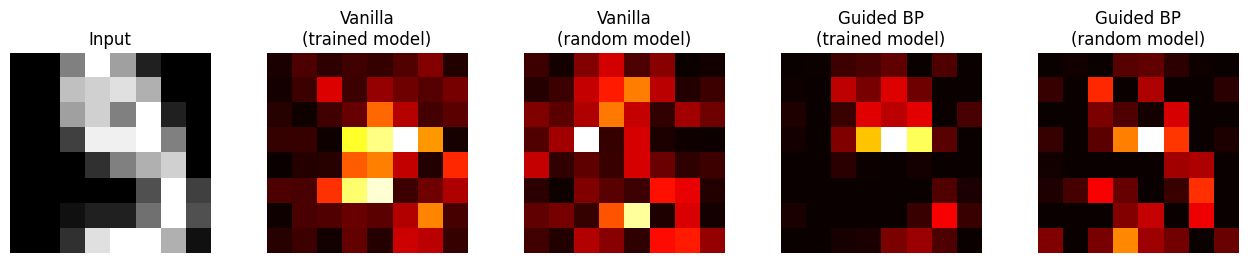

In [12]:
i0 = 3
x0 = X_test_c[i0:i0 + 1]
pred = cnn.predict(x0)[0]
s_trained = saliency_map(cnn, x0, pred)
s_random = saliency_map(rand_cnn, x0, pred)
g_trained = saliency_map(cnn, x0, pred, guided=True)
g_random = saliency_map(rand_cnn, x0, pred, guided=True)

fig, axes = plt.subplots(1, 5, figsize=(13, 2.6))
axes[0].imshow(x0[0, 0], cmap='gray'); axes[0].set_title('Input'); axes[0].axis('off')
axes[1].imshow(np.abs(s_trained), cmap='hot'); axes[1].set_title('Vanilla\n(trained model)'); axes[1].axis('off')
axes[2].imshow(np.abs(s_random), cmap='hot'); axes[2].set_title('Vanilla\n(random model)'); axes[2].axis('off')
axes[3].imshow(np.maximum(g_trained, 0), cmap='hot'); axes[3].set_title('Guided BP\n(trained model)'); axes[3].axis('off')
axes[4].imshow(np.maximum(g_random, 0), cmap='hot'); axes[4].set_title('Guided BP\n(random model)'); axes[4].axis('off')
plt.tight_layout()
plt.savefig('interpretability_sanity_check.png', dpi=110, bbox_inches='tight')
plt.show()


This reproduces the headline finding of Adebayo et al. (2018) at toy scale: **guided
backprop's crisper-looking maps are largely an artifact of the input's local edge structure
and the ReLU-gating pattern, not of what the specific trained weights learned** — its
explanation for a completely untrained, randomly-initialized network looks substantially
similar (cosine similarity ≈ 0.57) to its explanation for the real, trained classifier.
Vanilla gradients, despite looking "messier," pass the sanity check cleanly (≈ −0.05,
essentially uncorrelated) — a visually convincing explanation is not the same thing as a
faithful one.


## Summary

| Question | Finding |
|---|---|
| Is `backward_from_class`'s gradient correct? | Yes — median error 1.7×10⁻¹⁰ vs. numerical gradients; the few outliers are explained exactly by max-pool argmax boundaries |
| Do these methods localize the digit? | Occlusion (0.88) ≫ vanilla saliency (0.57) > random baseline (0.44) > Grad-CAM (0.38) — Grad-CAM is bottlenecked by its 4×4 feature-map resolution on this tiny 8×8 dataset |
| Do gradient- and perturbation-based methods agree? | Only modestly (vanilla ↔ occlusion: r≈0.30); Grad-CAM ↔ occlusion is actually negative even at matched resolution |
| Which methods pass the weight-randomization sanity check? | Vanilla gradients: yes. Grad-CAM: partially. Guided backprop: no — it looks similar even on an untrained, random network |

The overall lesson: **a saliency map that "looks right" is not the same as a saliency map
that is right.** The only way to tell the difference is to run a check like Section 6 — is
the explanation actually different when the underlying model is a different function? — or
to cross-validate against a method with entirely different assumptions, like occlusion
sensitivity, that doesn't rely on gradients at all.
